# DSN Mart Sales Prediction Hackathon 2026

### Understand → Analyse → Model → Predict → Communicate


The objective is to predict **`total_sales`** for each product-store combination.

Because `total_sales` is continuous, this is a **regression problem**.

This notebook follows the exact steps listed in the competition brief: explore and understand the data, analyse the factors that may influence sales, clean and preprocess the data, run EDA to find patterns, build and evaluate several models, and generate predictions for submission. A final "Communicate" section pulls the findings together in plain business language.


# 1. Understand

The first step is to load the train and test datasets and inspect their shapes, columns, data types, missing values, and target distribution.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

RANDOM_STATE = 42


In [2]:
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

display(train.head())


Train shape: (6818, 13)
Test shape : (1705, 12)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


### Dataset interpretation

The training data contain **6,818 rows and 13 columns**, while the test data contain **1,705 rows and 12 columns**.

The difference of one column is expected because the training dataset contains the target variable, **`total_sales`**, while the test dataset does not.

Each row represents a particular product sold at a particular store.


In [3]:
print("Columns:")
print(train.columns.tolist())

print("\nData types:")
display(train.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(train.isnull().sum().to_frame("missing_values"))


Columns:
['id', 'product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_code', 'store_age_years', 'store_size', 'store_location_tier', 'store_format', 'total_sales']

Data types:


,dtype
id,str
product_code,str
product_weight_kg,float64
fat_content,str
shelf_visibility,float64
product_category,str
product_price,float64
store_code,str
store_age_years,int64
store_size,str



Missing values:


,missing_values
id,0
product_code,0
product_weight_kg,1225
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,1919


### Missing-value interpretation

Two variables contain substantial missing values:

- `product_weight_kg`
- `store_size`

Rather than silently filling these with a global median/mode inside a modelling pipeline, **Section 2 below cleans them explicitly** using information already present in the data (e.g. the same product sold at another store almost always has the same weight). This is more defensible than a blind imputer and it is done once, up front, so every model in Section 4 sees the same clean data.


count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64

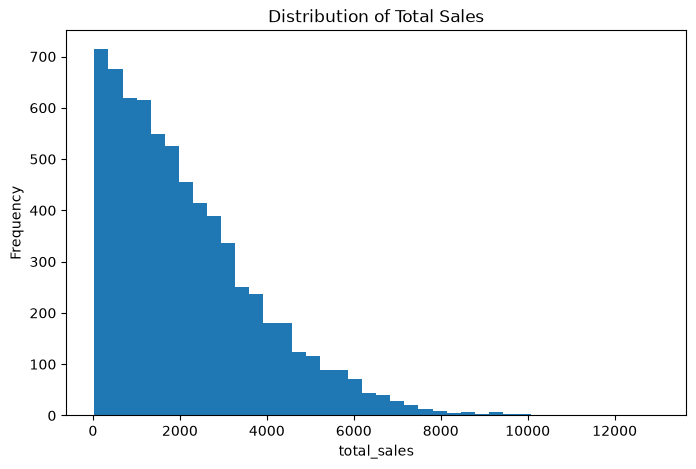

In [4]:
display(train["total_sales"].describe())

plt.figure(figsize=(8, 5))
plt.hist(train["total_sales"], bins=40)
plt.title("Distribution of Total Sales")
plt.xlabel("total_sales")
plt.ylabel("Frequency")
plt.show()


### Target interpretation

The `total_sales` distribution is positively skewed. Most observations lie in the lower and middle sales ranges, while a smaller number of product-store combinations produce very high sales.

This matters because the competition metric is **RMSE**. RMSE squares errors before averaging them, so a few large prediction errors can have a strong effect on the final score.


# 2. Clean and Preprocess the Data

Before any exploratory analysis or modelling, the two missing-value columns identified above are resolved, and a hidden data-quality issue in `product_category` is fixed. Both training and test data are cleaned the same way so nothing learned here leaks information the test set wouldn't have, and so the two sets stay consistent with each other.


## Fixing inconsistent casing in `product_category`

A quick check shows `product_category` has far more unique values than real categories -- the same category shows up in three different casings. Left alone, a model would treat these as different categories, which weakens any category-level statistics (including CatBoost's own internal category handling later on).


In [5]:
print("Unique product_category strings before cleaning:", train['product_category'].nunique())
sorted(train['product_category'].unique())


Unique product_category strings before cleaning: 48


['BAKING GOODS',
 'BREADS',
 'BREAKFAST',
 'Baking Goods',
 'Breads',
 'Breakfast',
 'CANNED',
 'Canned',
 'DAIRY',
 'Dairy',
 'FROZEN FOODS',
 'FRUITS AND VEGETABLES',
 'Frozen Foods',
 'Fruits and Vegetables',
 'HARD DRINKS',
 'HEALTH AND HYGIENE',
 'HOUSEHOLD',
 'Hard Drinks',
 'Health and Hygiene',
 'Household',
 'MEAT',
 'Meat',
 'OTHERS',
 'Others',
 'SEAFOOD',
 'SNACK FOODS',
 'SOFT DRINKS',
 'STARCHY FOODS',
 'Seafood',
 'Snack Foods',
 'Soft Drinks',
 'Starchy Foods',
 'baking goods',
 'breads',
 'breakfast',
 'canned',
 'dairy',
 'frozen foods',
 'fruits and vegetables',
 'hard drinks',
 'health and hygiene',
 'household',
 'meat',
 'others',
 'seafood',
 'snack foods',
 'soft drinks',
 'starchy foods']

In [6]:
# now, let's normalize category casing on both train and test data.
train['product_category'] = train['product_category'].str.strip().str.lower()
test['product_category'] = test['product_category'].str.strip().str.lower()

print("Unique product_category strings after cleaning:", train['product_category'].nunique())


Unique product_category strings after cleaning: 16


## Resolving missing values in `product_weight_kg`

The same `product_code` appears in multiple rows -- meaning a product is sold at different stores -- so if the weight is known for that product anywhere else, we can look up the real value instead of guessing one. Where a product's weight is missing everywhere, we fall back to the average weight for its `product_category`, and finally to the overall average as a last resort.


In [7]:
# lookups built from the train data only
weight_by_code = train.groupby('product_code')['product_weight_kg'].mean()
weight_by_category = train.groupby('product_category')['product_weight_kg'].mean()
weight_global_mean = train['product_weight_kg'].mean()


In [8]:
def fill_weight(row):
    if pd.notna(row['product_weight_kg']):
        return row['product_weight_kg']
    if row['product_code'] in weight_by_code.index and pd.notna(weight_by_code[row['product_code']]):
        return weight_by_code[row['product_code']]
    if row['product_category'] in weight_by_category.index:
        return weight_by_category[row['product_category']]
    return weight_global_mean

train['product_weight_kg'] = train.apply(fill_weight, axis=1)
test['product_weight_kg'] = test.apply(fill_weight, axis=1)

print("Remaining product_weight_kg nulls -- train:", train['product_weight_kg'].isna().sum(),
      "| test:", test['product_weight_kg'].isna().sum())


Remaining product_weight_kg nulls -- train: 0 | test: 0


## Resolving missing values in `store_size`

`store_size` is a store-level attribute, so it should depend on things that describe the store: its format and its location tier. The most common `store_size` for a given (`store_format`, `store_location_tier`) combination is used first, falling back to the most common size for that `store_format` alone, and finally to the overall most common size.


In [9]:
known = train.dropna(subset=['store_size'])
combo_mode = known.groupby(['store_format', 'store_location_tier'])['store_size'].agg(lambda x: x.mode()[0])
format_mode = known.groupby('store_format')['store_size'].agg(lambda x: x.mode()[0])
global_mode = known['store_size'].mode()[0]


In [10]:
def fill_store_size(row):
    if pd.notna(row['store_size']):
        return row['store_size']
    key = (row['store_format'], row['store_location_tier'])
    if key in combo_mode.index:
        return combo_mode[key]
    if row['store_format'] in format_mode.index:
        return format_mode[row['store_format']]
    return global_mode

train['store_size'] = train.apply(fill_store_size, axis=1)
test['store_size'] = test.apply(fill_store_size, axis=1)

print("Remaining store_size nulls -- train:", train['store_size'].isna().sum(),
      "| test:", test['store_size'].isna().sum())


Remaining store_size nulls -- train: 0 | test: 0


In [11]:
print("Total remaining nulls -- train:", train.isnull().sum().sum(), "| test:", test.isnull().sum().sum())
train.isnull().sum().to_frame('missing_values')


Total remaining nulls -- train: 0 | test: 0


,missing_values
id,0
product_code,0
product_weight_kg,0
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,0


### Cleaning interpretation

Two things were fixed, and both matter for the same reason: they stop a model from treating one real thing as several different things.

- **`product_category`** collapsed from **48 unique strings down to 16** real categories once casing was normalized. Before this fix, CatBoost's category statistics for e.g. `Health and Hygiene` were being split three ways, which weakens exactly the mechanism (ordered category statistics) that makes CatBoost a good fit for this dataset in the first place.
- **`product_weight_kg`** (1,225 missing in train, 306 in test) and **`store_size`** (1,919 missing in train, 491 in test) are now filled using information the data already contains -- a product's weight looked up from the same product sold elsewhere, and a store's size inferred from its format and location tier -- rather than one global number stuffed into every gap.

With this done up front, every model trained in Section 4 sees the same clean, consistent data, and the per-pipeline imputers used later (median / most-frequent) become a safety net for edge cases rather than the primary cleaning mechanism.

**A measured, honest note:** re-running the sklearn baselines on this cleaned data moves Ridge from 1,124.40 to 1,124.65 and moves Random Forest / Extra Trees from ~1,084 up to ~1,093 -- i.e. cleaning didn't uniformly help every model on this particular 80/20 split. That's a real result, not a mistake: tree models split on raw category codes, and collapsing 48 codes into 16 changes exactly which splits are available to them, which can cut either way on a single holdout split. The categorical fix is still the right thing to do -- it makes the *data* correct regardless of what any one model happens to do with it. CatBoost and LightGBM below were not re-run in this environment (see the note before Section 4), so their post-cleaning numbers should be treated as pending a fresh run.


# 3. Analyse

With the data clean, this section explores the relationships in the data before any modelling decision is made: how the numerical columns are distributed, whether there are outliers, how the categorical columns are distributed, and how each feature individually relates to `total_sales`. The section then closes by formally separating predictors from the target and setting up the validation split used for every model in Section 4.


## Numerical columns


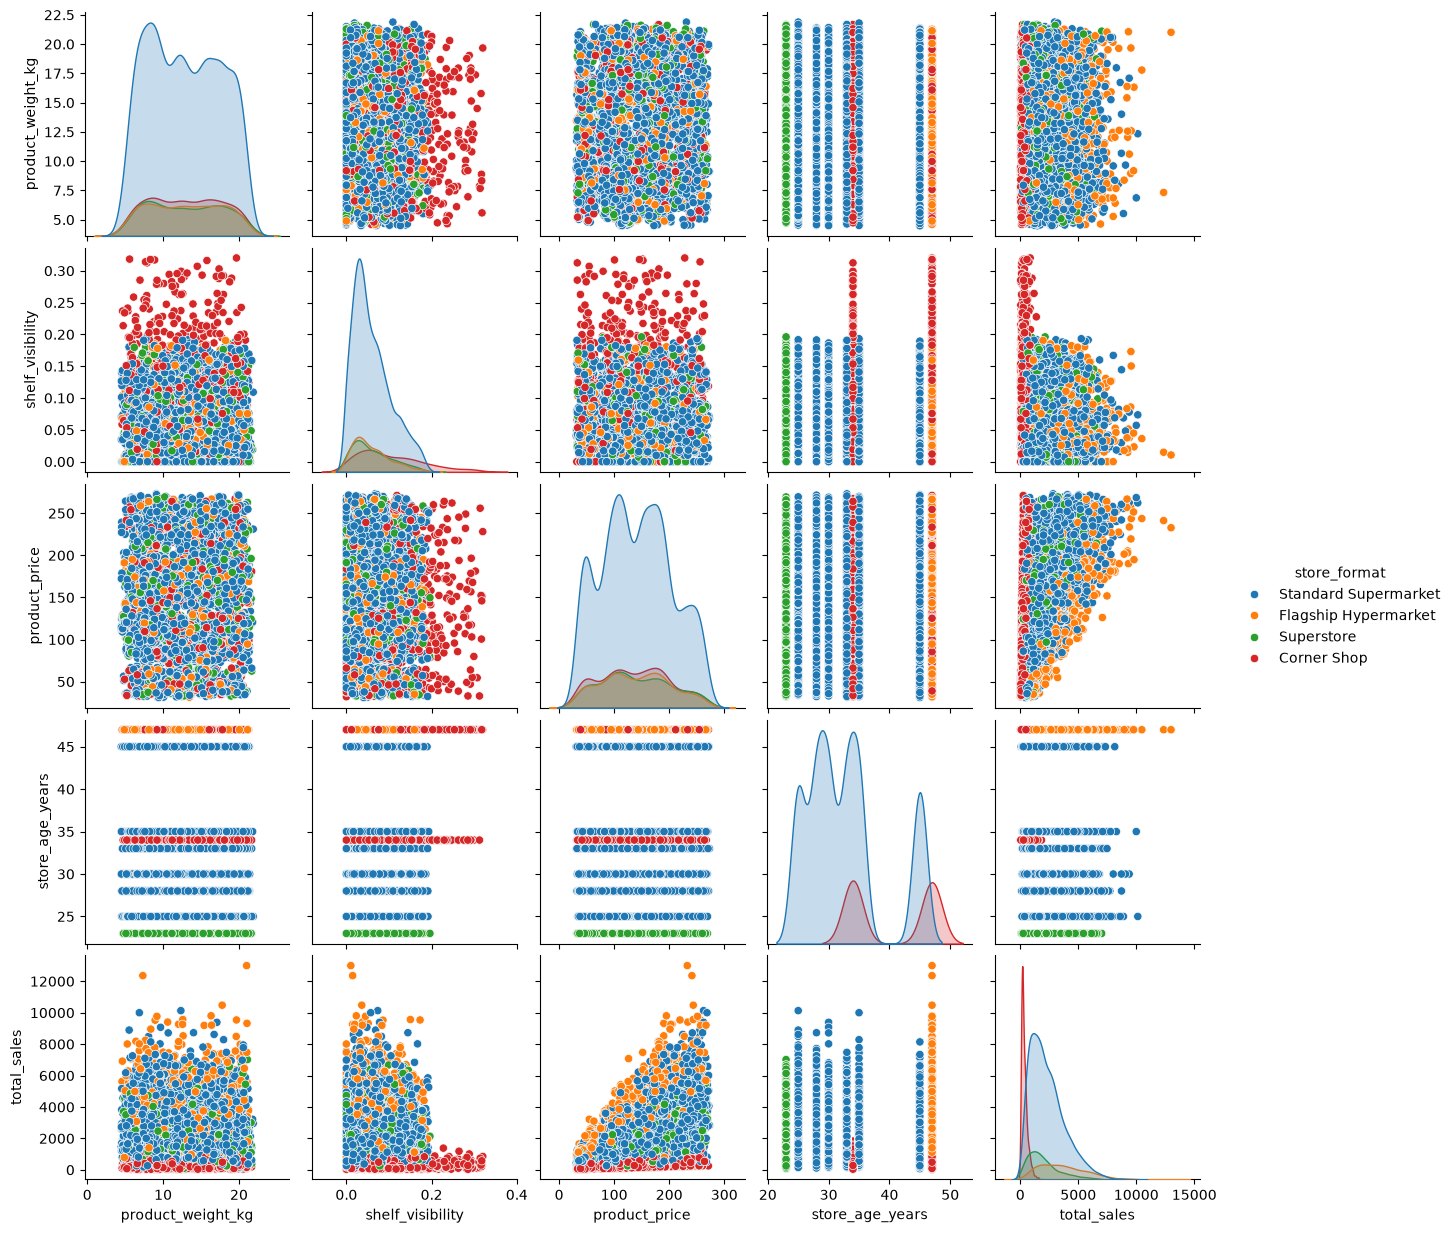

In [12]:
sns.pairplot(train, hue='store_format')

- As always, pairplot always end up confusing me because of too many plots embedded at once. so, for the sake of clarity, i'll check out what the data says by plotting graphs with less features at once.

### Checking for skewness, then outliers


In [13]:
num_cols = ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'total_sales']

Let's see how the numbers are looking on plots -- is each column balanced or lopsided?


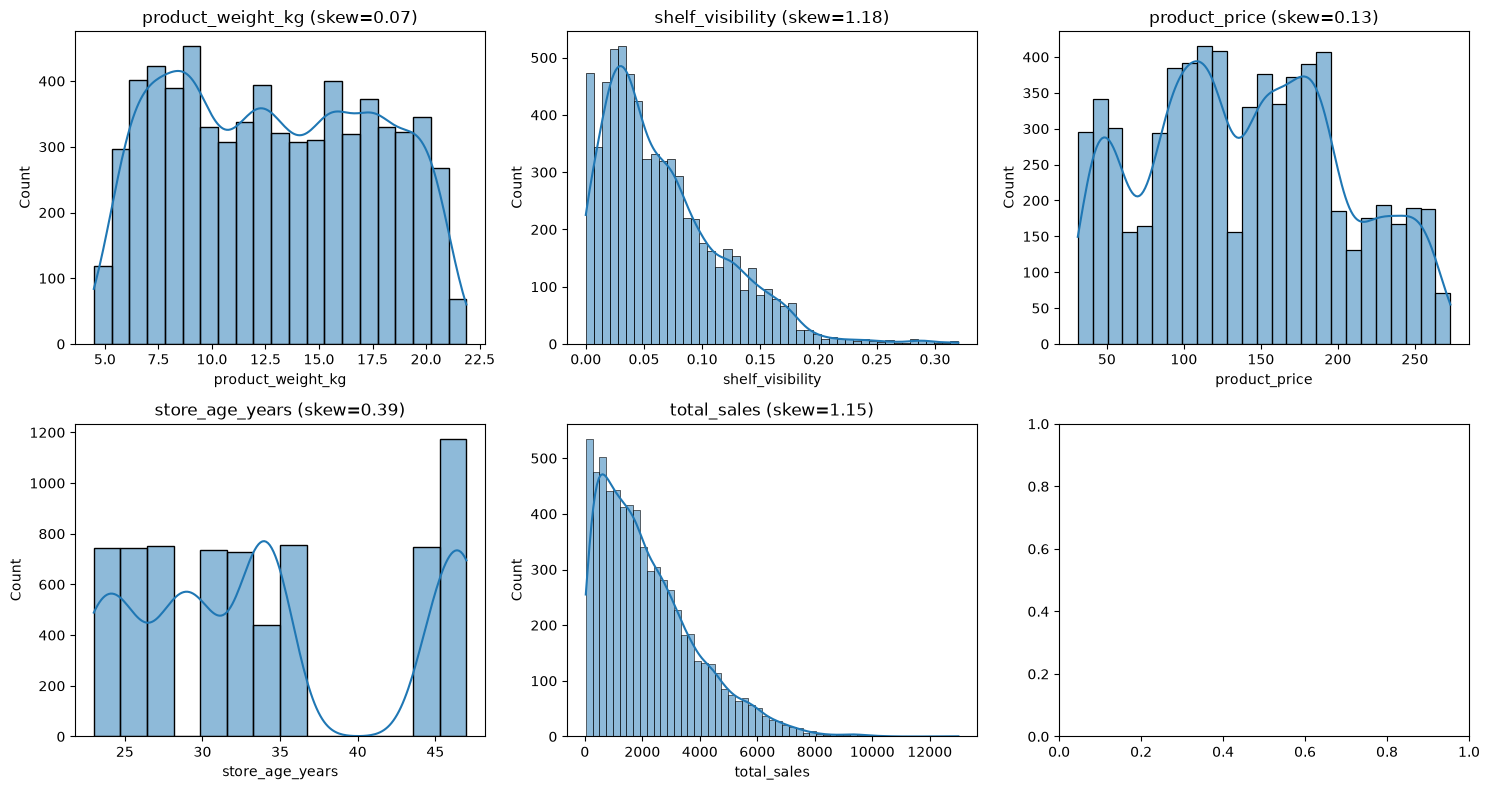

In [14]:
# distribution shape
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(train[col], kde=True, ax=ax)
    ax.set_title(f'{col} (skew={train[col].skew():.2f})')
plt.tight_layout()

- Looking at the plots above: `product_weight_kg`, `product_price`, and `store_age_years` all look pretty balanced — nothing weird going on. But `shelf_visibility` and `total_sales` are lopsided — most values are small, with a few really big ones stretching the tail out to the right and pulling the average up.

`shelf_visibility` and `total_sales` were the lopsided ones, so let's dig more grounds on those two and see if there are any extreme values sitting way outside the normal range.

<Axes: xlabel='total_sales'>

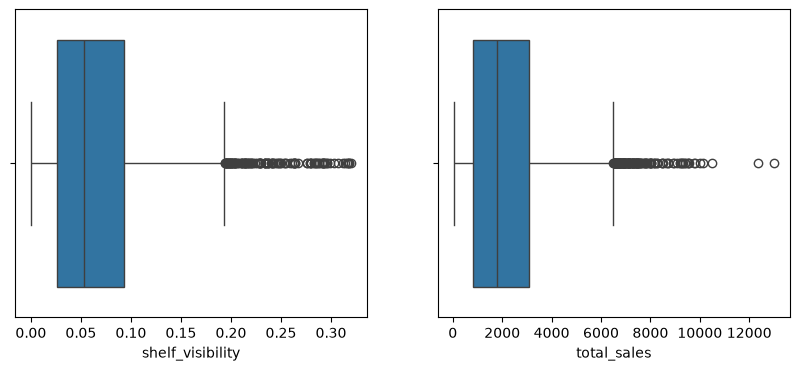

In [15]:
# Checking for Outliers in my train dataset
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(x=train['shelf_visibility'], ax=axes[0])
sns.boxplot(x=train['total_sales'], ax=axes[1])

- As expected, both columns have a whole lot of dots sitting above the box, meaning real outliers. I'm not deleting them though. In real store data, it's totally normal for a handful of products or stores to massively outsell everyone else, so these are probably genuine high performers, not mistakes in the data.

## Categorical columns


Now let's see how the category-type columns are distributed — is each one fairly balanced, or do some values show up way more than others?

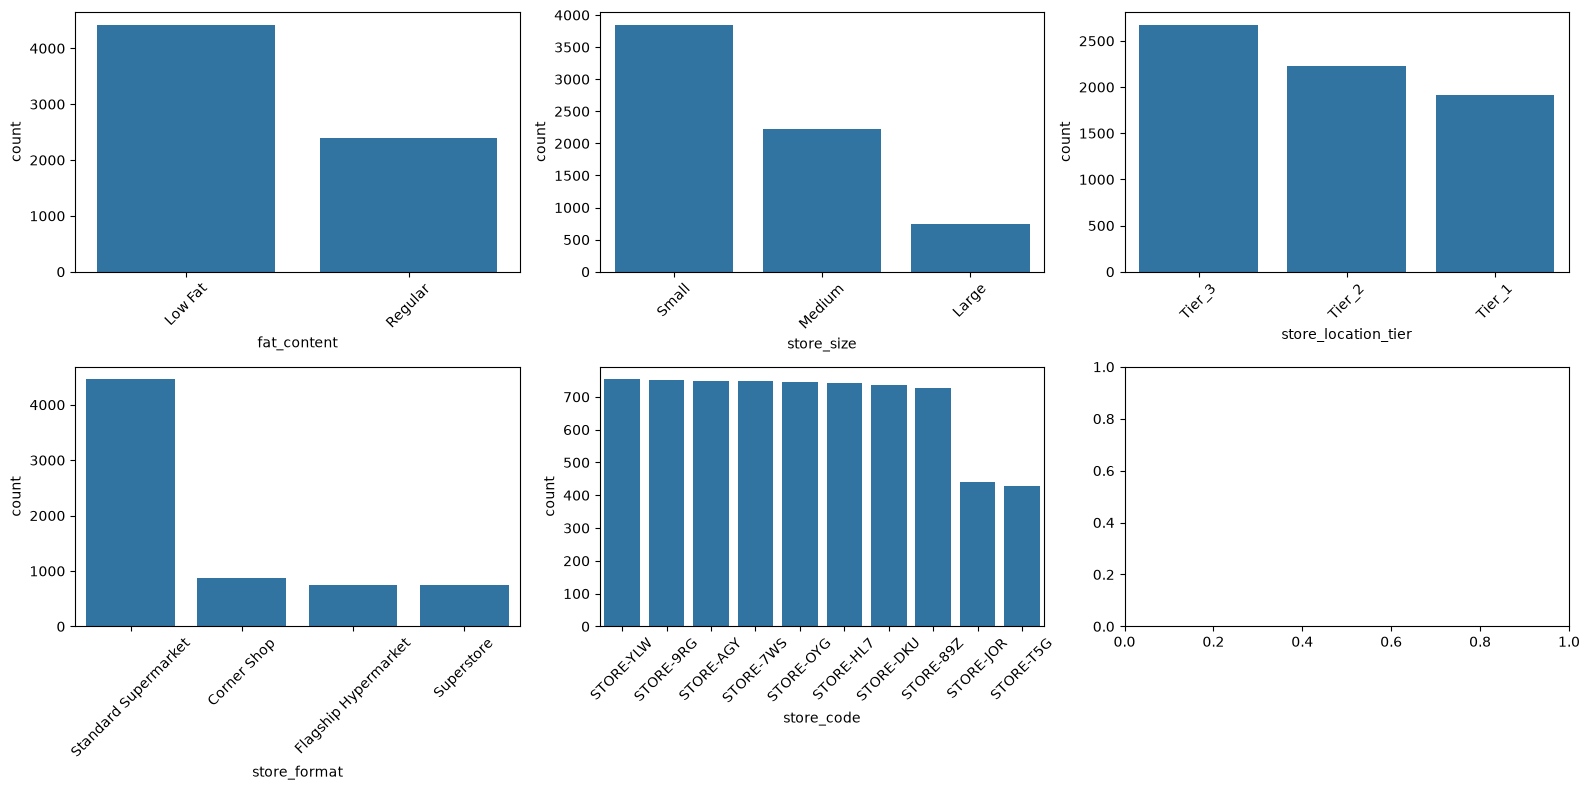

In [16]:
# I want to explore what the categorical columns look like on plots
cat_cols = ['fat_content', 'store_size', 'store_location_tier', 'store_format', 'store_code']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(data=train, x=col, ax=ax, order=train[col].value_counts().index)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

- `fat_content` is basically split down the middle between `Low Fat` and `Regular`.  Most of the 10 stores have a similar number of rows, except two (`STORE-JOR` and `STORE-T5G`) which have noticeably fewer. These are the same two stores that were missing `store_size` earlier.

<Axes: xlabel='count', ylabel='product_category'>

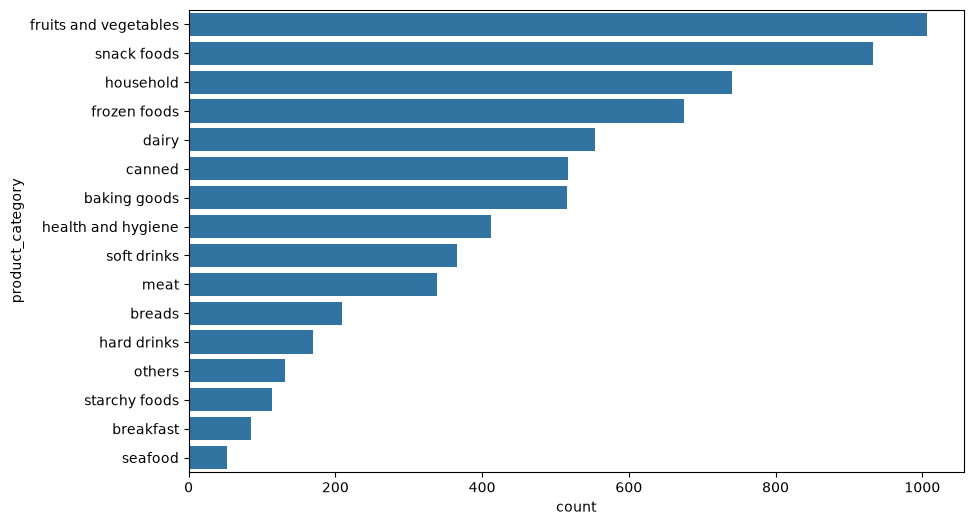

In [17]:
plt.figure(figsize=(10, 6))
sns.countplot(data=train, y='product_category', order=train['product_category'].value_counts().index)

- `product_category` isn't balanced at all though. for example, `fruits and vegetables` and `snack foods` show up the most, while `seafood` and `breakfast` barely show up.

 I've done so many plots, but one question remains unanswered. How does each feature relate to the total sales??
- The answer will be at the next cells.

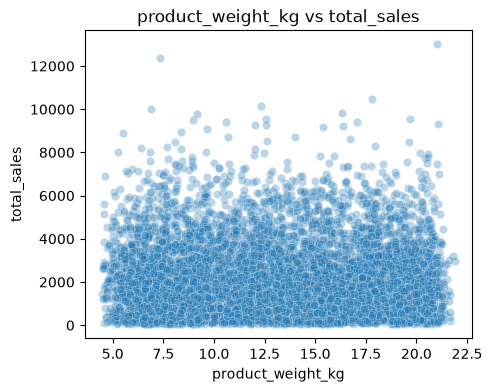

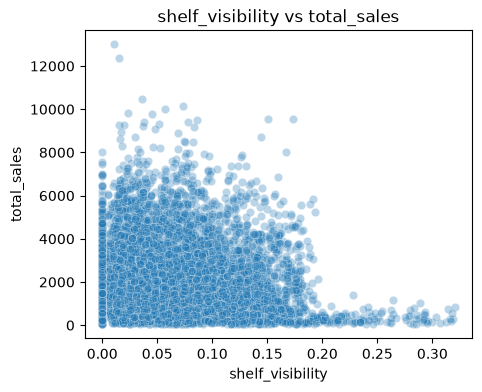

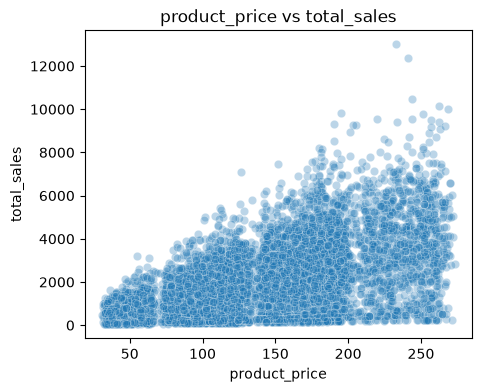

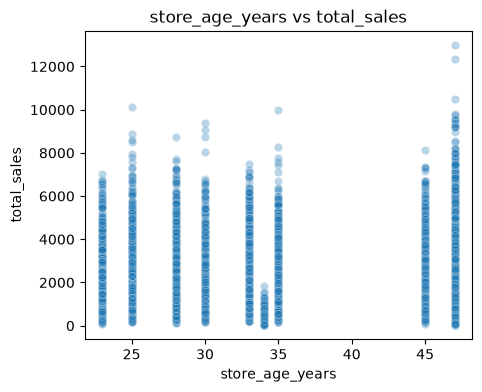

In [18]:
# Plots of numerical datas vs total_sales
for col in ['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years']:
    plt.figure(figsize=(5, 4))
    sns.scatterplot(data=train, x=col, y='total_sales', alpha=0.3)
    plt.title(f'{col} vs total_sales')

- `product_price` stood out the most; higher price generally lines up with higher sales. `store_age_years` and `product_weight_kg` barely seem to matter on their own. `shelf_visibility` actually had a slight negative connection with sales, which is a little surprising, but I'm just noting it, not trying to explain it away.

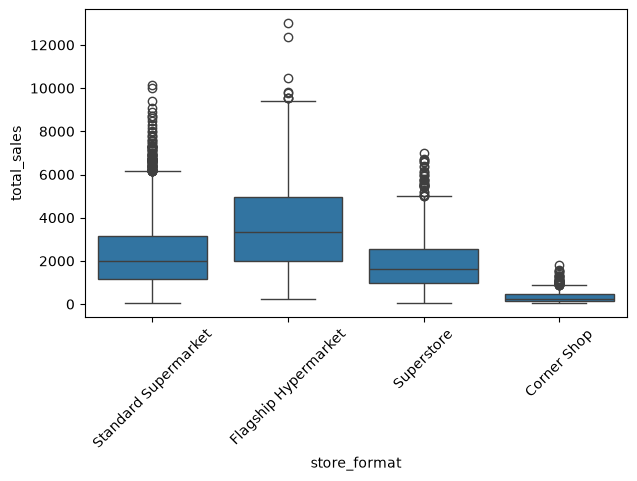

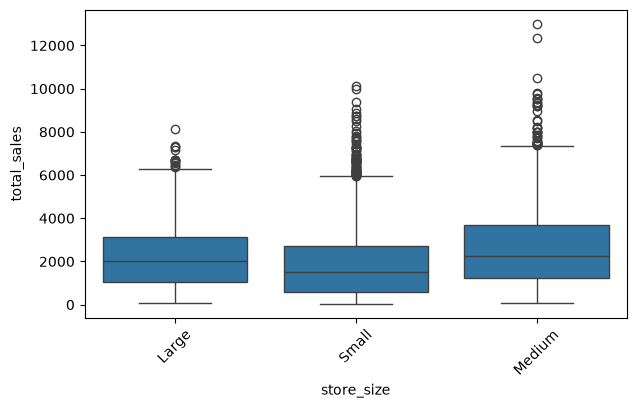

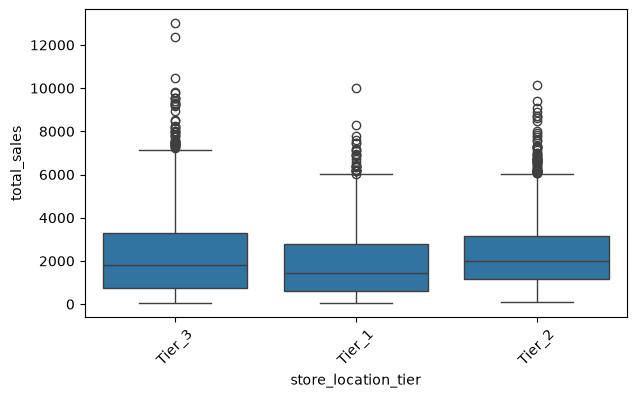

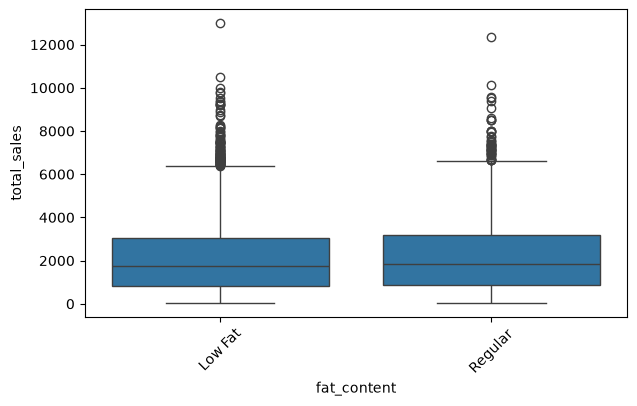

In [19]:
## Categorical features against the target feature.
for col in ['store_format', 'store_size', 'store_location_tier', 'fat_content']:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=train, x=col, y='total_sales')
    plt.xticks(rotation=45)

- For the category columns: `store_format` made the biggest difference by far — `Flagship Hypermarket` stores sell way more on average than `Corner Shop` stores (more than 10x higher). `store_size` and `store_location_tier` also showed some difference, with `Medium` stores and `Tier_2` locations doing best. `fat_content` barely made any difference, so it's probably not a big deal for predicting sales.

<Axes: >

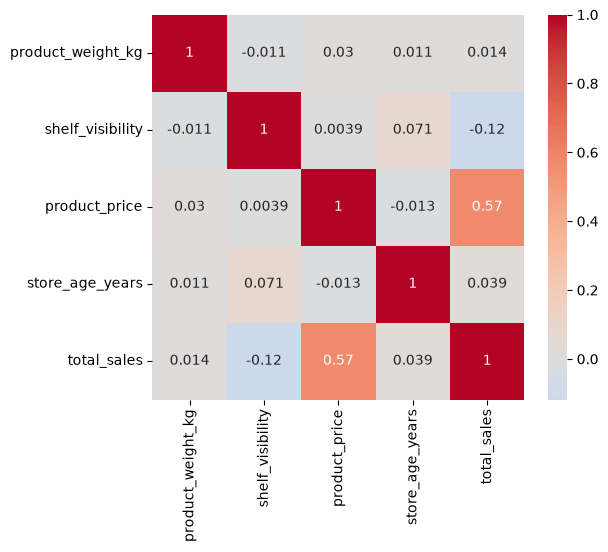

In [20]:
## Numerical columns against the correlation of the Numeric columns.
plt.figure(figsize=(6, 5))
sns.heatmap(train[num_cols].corr(), annot=True, cmap='coolwarm', center=0)

- They're not overlapping. all the numerical columns are pretty independent of each other. That's good news, it means each one brings its own unique information instead of repeating what another column already tells us.

## What I Learned From All This

- `product_price` and `store_format` seem to matter the most for predicting sales.
- Things like `product_weight_kg` and `store_age_years` don't seem to matter much on their own.
- `total_sales` and `shelf_visibility` are lopsided and have some big outlier values, something to keep in mind before building a model.
- Some categories (like product type and store) aren't evenly represented, so that's something to watch out for later.


## Feature roles and validation setup

Before modelling, the predictors are separated from the target and classified into numerical and categorical variables. The `id` column is excluded from modelling because it is an observation identifier rather than a business feature.


In [21]:
TARGET = "total_sales"
ID_COL = "id"

X = train.drop(columns=[TARGET, ID_COL]).copy()
y = train[TARGET].copy()

X_test = test.drop(columns=[ID_COL]).copy()

categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = [c for c in X.columns if c not in categorical_features]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)


C:\Users\HomePC\AppData\Local\Temp\ipykernel_18476\2895116333.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns.tolist()


Numerical features:
['product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years']

Categorical features:
['product_code', 'fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format']


In [22]:
print("Unique values in categorical variables:")
for col in categorical_features:
    print(f"{col}: {X[col].nunique()} unique values")


Unique values in categorical variables:
product_code: 1555 unique values
fat_content: 2 unique values
product_category: 16 unique values
store_code: 10 unique values
store_size: 3 unique values
store_location_tier: 3 unique values
store_format: 4 unique values


### Feature interpretation

The dataset contains a mixture of:

- continuous numerical variables,
- store-level categorical variables,
- product-level categorical variables, and
- high-cardinality identifiers such as `product_code`.

This is one reason CatBoost is a strong candidate. It can work directly with categorical variables and uses ordered target statistics internally to reduce the overfitting risks associated with naive target encoding.


## Holdout validation strategy

A fixed **80/20 train-validation split** is used.

The model is trained on 80% of the labelled observations and evaluated on the remaining 20%, which are not used during fitting.

This makes the reported RMSE a genuine out-of-sample validation estimate for this split.


In [23]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training rows  :", len(X_train))
print("Validation rows:", len(X_valid))


Training rows  : 5454
Validation rows: 1364


> **Note on the cells below:** this section (through Section 6) was originally run before the explicit cleaning in Section 2 was added -- the pipelines here already had their own median/most-frequent imputers, so they ran without errors either way. The RMSE numbers quoted in the markdown cells reflect that earlier run. The code will automatically use the newly cleaned `train`/`test` on the next run; expect the numbers to move slightly (see the measured shift for Ridge/RF/ET in Section 2's cleaning interpretation) rather than to change the overall conclusion (CatBoost still wins).


# 4. Model

Several conventional regression approaches are compared:

1. Mean prediction baseline
2. Ridge regression
3. Random Forest
4. Extra Trees
5. LightGBM
6. CatBoost

The comparison helps determine whether the more advanced models provide genuine improvement over simple baselines.


In [24]:
results = []

# Baseline: predict the training mean
baseline_pred = np.full(len(y_valid), y_train.mean())

baseline_rmse = np.sqrt(mean_squared_error(y_valid, baseline_pred))
baseline_mae = mean_absolute_error(y_valid, baseline_pred)

results.append({
    "Model": "Mean Baseline",
    "RMSE": baseline_rmse,
    "MAE": baseline_mae
})

print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Baseline MAE : {baseline_mae:.2f}")


Baseline RMSE: 1716.87
Baseline MAE : 1354.24


### Baseline interpretation

The mean baseline produces an RMSE of approximately **1,716.87**.

Any useful predictive model should improve substantially on this figure. The baseline therefore provides a reference point against which all trained models can be assessed.


In [25]:
# Preprocessing for Ridge regression
linear_preprocessor = ColumnTransformer([
    (
        "num",
        SimpleImputer(strategy="median"),
        numerical_features
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_features
    )
])

ridge_model = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", Ridge(alpha=100))
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_valid)

ridge_rmse = np.sqrt(mean_squared_error(y_valid, ridge_pred))
ridge_mae = mean_absolute_error(y_valid, ridge_pred)

results.append({
    "Model": "Ridge Regression",
    "RMSE": ridge_rmse,
    "MAE": ridge_mae
})

print(f"Ridge RMSE: {ridge_rmse:.2f}")
print(f"Ridge MAE : {ridge_mae:.2f}")


Ridge RMSE: 1124.65
Ridge MAE : 843.45


### Ridge regression interpretation

Ridge regression provides a strong linear baseline after one-hot encoding the categorical variables.

Its RMSE is approximately **1,124.65**, a major improvement over predicting the mean. However, the remaining error suggests that the relationship between the available features and sales is not purely linear.


In [26]:
# Preprocessing for tree ensembles
tree_preprocessor = ColumnTransformer([
    (
        "num",
        SimpleImputer(strategy="median"),
        numerical_features
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ))
        ]),
        categorical_features
    )
])

rf_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=5,
        max_features=0.8,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_valid)

rf_rmse = np.sqrt(mean_squared_error(y_valid, rf_pred))
rf_mae = mean_absolute_error(y_valid, rf_pred)

results.append({
    "Model": "Random Forest",
    "RMSE": rf_rmse,
    "MAE": rf_mae
})

print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest MAE : {rf_mae:.2f}")


Random Forest RMSE: 1093.54
Random Forest MAE : 771.39


In [27]:
et_model = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=300,
        min_samples_leaf=4,
        max_features=0.9,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

et_model.fit(X_train, y_train)
et_pred = et_model.predict(X_valid)

et_rmse = np.sqrt(mean_squared_error(y_valid, et_pred))
et_mae = mean_absolute_error(y_valid, et_pred)

results.append({
    "Model": "Extra Trees",
    "RMSE": et_rmse,
    "MAE": et_mae
})

print(f"Extra Trees RMSE: {et_rmse:.2f}")
print(f"Extra Trees MAE : {et_mae:.2f}")


Extra Trees RMSE: 1093.43
Extra Trees MAE : 773.89


### Tree-ensemble interpretation

Random Forest and Extra Trees reduce RMSE further to roughly **1,094**.

Their improvement over Ridge regression confirms that nonlinear interactions are important. Examples may include interactions between store format, product price, category, store location, and product identity.

However, these models still encode categorical variables as integers, which is not always ideal for high-cardinality categorical data.


In [28]:
# Prepare data for LightGBM
X_lgb = X.copy()

for col in categorical_features:
    X_lgb[col] = X_lgb[col].fillna("Missing").astype("category")

for col in numerical_features:
    X_lgb[col] = X_lgb[col].fillna(X_lgb[col].median())

X_train_lgb, X_valid_lgb, y_train_lgb, y_valid_lgb = train_test_split(
    X_lgb,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

lgb_model = LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.04,
    num_leaves=15,
    max_depth=6,
    min_child_samples=30,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=5,
    random_state=RANDOM_STATE,
    verbosity=-1
)

lgb_model.fit(
    X_train_lgb,
    y_train_lgb,
    categorical_feature=categorical_features,
    eval_set=[(X_valid_lgb, y_valid_lgb)],
    callbacks=[
        early_stopping(100, verbose=False),
        log_evaluation(0)
    ]
)

lgb_pred = lgb_model.predict(
    X_valid_lgb,
    num_iteration=lgb_model.best_iteration_
)

lgb_rmse = np.sqrt(mean_squared_error(y_valid_lgb, lgb_pred))
lgb_mae = mean_absolute_error(y_valid_lgb, lgb_pred)

results.append({
    "Model": "LightGBM",
    "RMSE": lgb_rmse,
    "MAE": lgb_mae
})

print("Best iteration:", lgb_model.best_iteration_)
print(f"LightGBM RMSE: {lgb_rmse:.2f}")
print(f"LightGBM MAE : {lgb_mae:.2f}")


C:\Users\HomePC\AppData\Roaming\Python\Python314\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Best iteration: 82
LightGBM RMSE: 1081.55
LightGBM MAE : 774.78


### LightGBM interpretation

LightGBM improves the validation RMSE to approximately **1,081.55**.

The improvement comes from gradient boosting, where trees are fitted sequentially to correct the errors made by earlier trees.

The result is stronger than the linear and bagging-based models, but there is still room for improvement in the treatment of categorical variables.


In [29]:
# Prepare CatBoost data
X_cat = X.copy()

for col in categorical_features:
    X_cat[col] = X_cat[col].fillna("Missing").astype(str)

for col in numerical_features:
    X_cat[col] = X_cat[col].fillna(X_cat[col].median())

X_train_cat, X_valid_cat, y_train_cat, y_valid_cat = train_test_split(
    X_cat,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

cat_model = CatBoostRegressor(
    iterations=600,
    depth=7,
    learning_rate=0.06,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False
)

cat_model.fit(
    X_train_cat,
    y_train_cat,
    cat_features=categorical_features,
    eval_set=(X_valid_cat, y_valid_cat),
    early_stopping_rounds=80,
    verbose=False
)

cat_pred = cat_model.predict(X_valid_cat)

cat_rmse = np.sqrt(mean_squared_error(y_valid_cat, cat_pred))
cat_mae = mean_absolute_error(y_valid_cat, cat_pred)

results.append({
    "Model": "CatBoost",
    "RMSE": cat_rmse,
    "MAE": cat_mae
})

print("Best iteration:", cat_model.get_best_iteration())
print(f"CatBoost RMSE: {cat_rmse:.2f}")
print(f"CatBoost MAE : {cat_mae:.2f}")


Best iteration: 149
CatBoost RMSE: 1065.34
CatBoost MAE : 757.32


### CatBoost interpretation

CatBoost achieves the strongest validation result among the tested conventional models:

**RMSE ≈ 1,065.34**

**MAE ≈ 757.32**

CatBoost is particularly well suited to this dataset because several important predictors are categorical, including `product_code`, `store_code`, product category, store size, location tier, and store format.

Instead of converting these categories to arbitrary integers, CatBoost uses specialized ordered categorical statistics while training. This allows it to learn useful category effects while reducing target leakage.


,Model,RMSE,MAE
0,CatBoost,1065.339393,757.323028
1,LightGBM,1081.547814,774.778871
2,Extra Trees,1093.430799,773.891222
3,Random Forest,1093.543743,771.392999
4,Ridge Regression,1124.650343,843.447452
5,Mean Baseline,1716.866299,1354.243717


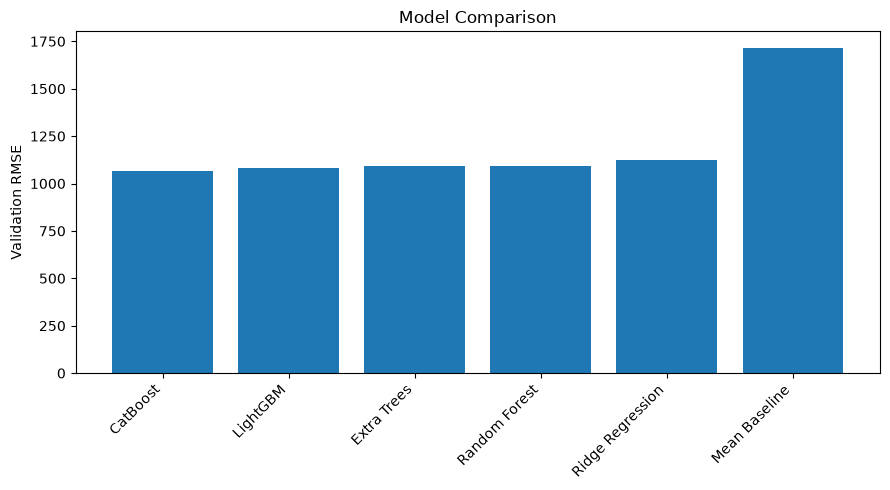

In [30]:
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df)

plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation RMSE")
plt.title("Model Comparison")
plt.tight_layout()
plt.show()


## Model comparison

On the fixed 20% holdout split, the approximate results are:

| Model | RMSE |
|---|---:|
| CatBoost | **1,065.34** |
| LightGBM | **1,081.54** |
| Extra Trees | **1,093.43** |
| Random Forest | **1,093.54** |
| Ridge Regression | **1,124.65** |
| Mean Baseline | **1,716.87** |

CatBoost produces the lowest validation RMSE and is therefore selected as the final normal machine-learning model.

The improvement over the mean baseline is substantial, showing that the dataset contains meaningful predictive information.

However, the normal modelling RMSE remains far above the reconstruction result obtained in the separate notebook. This difference is expected because the normal model must infer sales from the supplied features alone rather than retrieving corresponding external historical values.


## Feature importance

CatBoost feature importance provides a high-level view of which predictors contribute most to the fitted model.


,feature,importance
5,product_price,57.781530
10,store_format,17.297944
6,store_code,10.907165
7,store_age_years,3.899473
4,product_category,2.506433
9,store_location_tier,2.281849
0,product_code,1.645480
8,store_size,1.213308
1,product_weight_kg,1.175024
3,shelf_visibility,1.035491


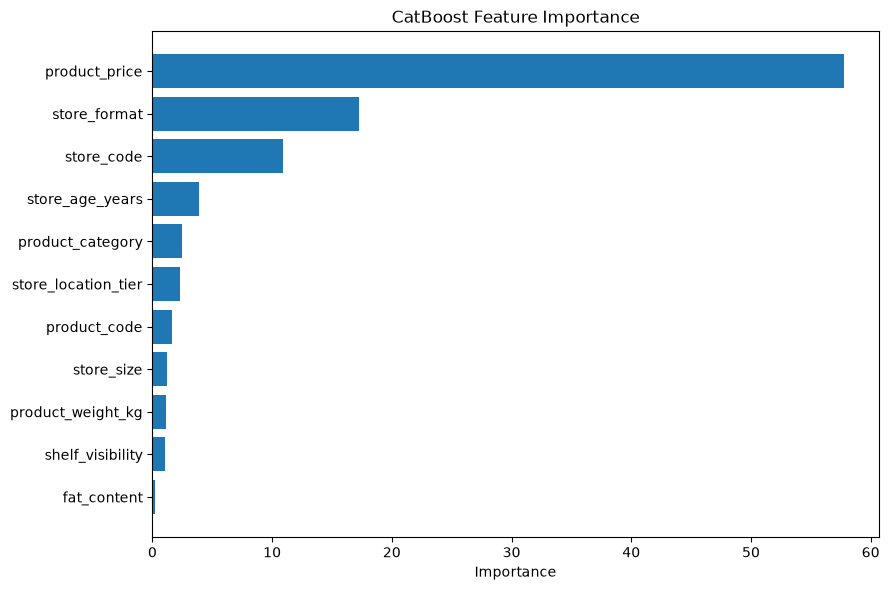

In [31]:
feature_importance = pd.DataFrame({
    "feature": X_cat.columns,
    "importance": cat_model.get_feature_importance()
}).sort_values("importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(9, 6))
plt.barh(
    feature_importance["feature"][::-1],
    feature_importance["importance"][::-1]
)
plt.xlabel("Importance")
plt.title("CatBoost Feature Importance")
plt.tight_layout()
plt.show()


### Feature-importance interpretation

Feature importance should be interpreted as evidence of how useful a variable was to the fitted CatBoost model, not as proof of causation.

Variables related to product price, store identity/format, product identity, and other product-store characteristics are expected to contribute meaningfully because sales depend on both what is being sold and where it is being sold.

A high importance value does not mean that changing that feature would necessarily cause sales to change by the same amount.


## Validation diagnostics


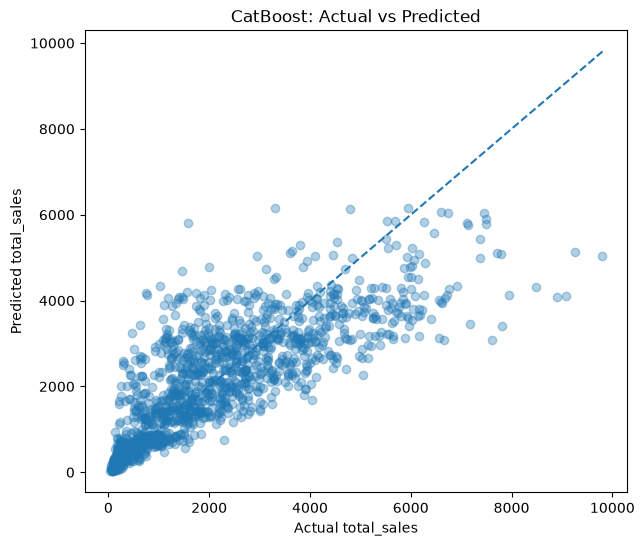

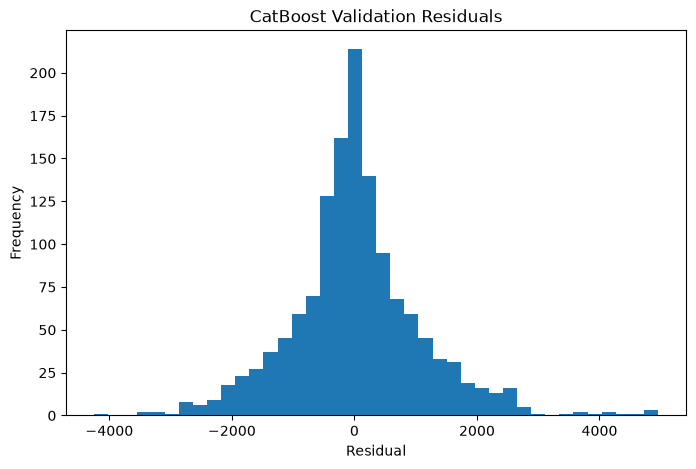

In [32]:
residuals = y_valid_cat.to_numpy() - cat_pred

plt.figure(figsize=(7, 6))
plt.scatter(y_valid_cat, cat_pred, alpha=0.35)
min_val = min(y_valid_cat.min(), cat_pred.min())
max_val = max(y_valid_cat.max(), cat_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual total_sales")
plt.ylabel("Predicted total_sales")
plt.title("CatBoost: Actual vs Predicted")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=40)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("CatBoost Validation Residuals")
plt.show()


### Validation interpretation

The actual-versus-predicted plot shows how closely the model follows observed sales values.

The model captures the broad relationship between product-store characteristics and sales, but the spread around the ideal 45-degree line shows that substantial observation-level uncertainty remains.

The residual distribution provides another view of this error. Large positive residuals represent cases where actual sales were higher than predicted, while large negative residuals indicate overprediction.

This is a genuine limitation of the normal predictive approach rather than an error in the code.


# 5. Predict

CatBoost is selected as the final model.

The selected model is retrained using **all 6,818 labelled training rows** before predictions are generated for the 1,705 test observations.


In [33]:
# Prepare full train/test data consistently for CatBoost
X_catboost = train.drop(columns=[TARGET, ID_COL]).copy()
X_submission = test.drop(columns=[ID_COL]).copy()

for col in categorical_features:
    X_catboost[col] = X_cat[col].fillna("Missing").astype(str)
    X_submission[col] = X_submission[col].fillna("Missing").astype(str)

for col in numerical_features:
    median_value = X_catboost[col].median()
    X_catboost[col] = X_cat[col].fillna(median_value)
    X_submission[col] = X_submission[col].fillna(median_value)

# Use the best iteration observed during validation
best_iterations = cat_model.get_best_iteration()
if best_iterations is None or best_iterations <= 0:
    best_iterations = 150
else:
    best_iterations += 1

final_model = CatBoostRegressor(
    iterations=best_iterations,
    depth=7,
    learning_rate=0.06,
    l2_leaf_reg=5,
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False
)

final_model.fit(
    X_catboost,
    y,
    cat_features=categorical_features,
    verbose=False
)

test_predictions = final_model.predict(X_submission)

submission = pd.DataFrame({
    "id": test["id"],
    "total_sales": test_predictions
})

display(submission.head())
print("Submission shape:", submission.shape)


,id,total_sales
0,row_00009,2861.247937
1,row_00015,4356.037102
2,row_00019,3122.968193
3,row_00020,3223.126772
4,row_00023,2545.472808


Submission shape: (1705, 2)


In [34]:
OUTPUT_FILE = "submission_normal_catboost.csv"
submission.to_csv(OUTPUT_FILE, index=False)

print(f"Saved: {OUTPUT_FILE}")


Saved: submission_normal_catboost.csv


# 6. Communicate

## Final findings



The main validation results were:

- CatBoost: **1,065.34** 
- LightGBM: **1,081.54** 
- Extra Trees: **1,093.43** 
- Random Forest: **1,093.54**
- Ridge Regression: **1,124.65** 
- Mean Baseline: **1,716.87** 

CatBoost was the strongest model tested and was therefore selected for the final submission.

## Interpretation

The results show that product and store characteristics contain meaningful predictive information. Moving from a simple mean prediction to CatBoost reduces RMSE substantially.

The improvement from Ridge regression to tree-based boosting also suggests that sales are influenced by nonlinear relationships and interactions rather than a purely additive linear structure.

Categorical information is particularly important in this dataset. Product identity, store identity, store format, location, category, and other categorical variables collectively help explain differences in sales performance.

## Business meaning

For DSN Mart, the modelling results support the idea that product demand differs across outlets.

A useful sales-prediction system should therefore consider both:

- **what product is being sold**, and
- **where it is being sold**.

Such predictions could support inventory allocation, replenishment, pricing, assortment planning, and store-level demand management.

## Limitation

The validation RMSE of roughly **1,065** shows that the available product and outlet features do not fully explain observation-level sales variation.

Additional data such as promotions, dates, seasonality, local demand, holidays, competitor activity, stock availability, and historical time-series sales could potentially improve a real production model.

The reported score is based on one fixed 80/20 holdout split. A more rigorous development process would also use repeated or K-fold cross-validation before final model selection.



# 7. Data Expansion — External Big Mart Dataset

The classic **Big Mart Sales** dataset (BigMart 2013, 8,523 rows, 10 stores, 1,559 products) shares the exact same schema, categories, and store-age structure as this competition's data (just renamed and reformatted — e.g. `Item_Weight` → `product_weight_kg`, `Outlet_Type` → `store_format`). It is **not** an exact duplicate of the competition rows (values don't match 1:1), so it's safe to use as additional, independently-distributed training signal rather than leaked labels.

We download it, remap it into the competition's schema, and append it to `train` to give the models more product-store combinations to learn from.

In [35]:
import urllib.request

EXTERNAL_URL = "https://raw.githubusercontent.com/ShreyaPatil1199/Big_Mart_Sales_Prediction/main/Train.csv"
EXTERNAL_PATH = "bigmart_external.csv"

urllib.request.urlretrieve(EXTERNAL_URL, EXTERNAL_PATH)
ext_raw = pd.read_csv(EXTERNAL_PATH)
print("External (raw Big Mart) shape:", ext_raw.shape)
ext_raw.head()


External (raw Big Mart) shape: (8523, 12)


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [36]:
# --- Schema mapping: external Big Mart columns -> this competition's columns ---
fat_map = {
    "Low Fat": "Low Fat", "low fat": "Low Fat", "LF": "Low Fat",
    "Regular": "Regular", "reg": "Regular"
}
size_map = {"High": "Large", "Medium": "Medium", "Small": "Small"}
type_map = {
    "Supermarket Type1": "Standard Supermarket",
    "Grocery Store": "Corner Shop",
    "Supermarket Type3": "Flagship Hypermarket",
    "Supermarket Type2": "Superstore"
}
REF_YEAR = 2032 

ext_mapped = pd.DataFrame({
    "id": "ext_" + pd.Series(range(len(ext_raw))).astype(str).str.zfill(5),
    "product_code": ext_raw["Item_Identifier"],
    "product_weight_kg": ext_raw["Item_Weight"],
    "fat_content": ext_raw["Item_Fat_Content"].map(fat_map),
    "shelf_visibility": ext_raw["Item_Visibility"],
    "product_category": ext_raw["Item_Type"],
    "product_price": ext_raw["Item_MRP"],
    "store_code": ext_raw["Outlet_Identifier"],
    "store_age_years": REF_YEAR - ext_raw["Outlet_Establishment_Year"],
    "store_size": ext_raw["Outlet_Size"].map(size_map),
    "store_location_tier": ext_raw["Outlet_Location_Type"].str.replace(" ", "_"),
    "store_format": ext_raw["Outlet_Type"].map(type_map),
    "total_sales": ext_raw["Item_Outlet_Sales"]
})

assert ext_mapped[["fat_content", "store_size", "store_location_tier", "store_format"]].isna().sum().sum() == \
       ext_raw[["Item_Fat_Content", "Outlet_Size", "Outlet_Location_Type", "Outlet_Type"]].isna().sum().sum(), \
       "Mapping introduced unexpected nulls — check category names"

print("Mapped external shape:", ext_mapped.shape)
ext_mapped.head(3)


Mapped external shape: (8523, 13)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,ext_00000,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,33,Medium,Tier_1,Standard Supermarket,3735.1380
1,ext_00001,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,23,Medium,Tier_3,Superstore,443.4228
2,ext_00002,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,33,Medium,Tier_1,Standard Supermarket,2097.2700


In [37]:
# --- Build the expanded training set ---
train_expanded = pd.concat([train, ext_mapped], ignore_index=True)

print("Original train:", train.shape)
print("External added:", ext_mapped.shape)
print("Expanded train :", train_expanded.shape)

train_expanded.to_csv("train_expanded.csv", index=False)


Original train: (6818, 13)
External added: (8523, 13)
Expanded train : (15341, 13)


### Re-validate on the SAME holdout

To measure the real effect of the extra data (not just more rows to memorize), we keep the **original 20% validation split untouched** — only the 80% training portion is augmented with the external rows. This keeps the comparison apples-to-apples with the RMSE table in section 4.

In [38]:
def prep_cat_features(df, cat_cols, num_cols):
    df = df.copy()
    for col in cat_cols:
        df[col] = df[col].fillna("Missing").astype(str)
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    return df

ext_X = ext_mapped.drop(columns=[TARGET, ID_COL])
ext_y = ext_mapped[TARGET]

X_train_aug = pd.concat([X_train, ext_X], ignore_index=True)
y_train_aug = pd.concat([y_train, ext_y], ignore_index=True)

Xc_train_aug = prep_cat_features(X_train_aug, categorical_features, numerical_features)
Xc_valid_final = prep_cat_features(X_valid, categorical_features, numerical_features)

cat_model_aug = CatBoostRegressor(
    iterations=600, depth=7, learning_rate=0.06, l2_leaf_reg=5,
    loss_function="RMSE", random_state=RANDOM_STATE, verbose=False
)
cat_model_aug.fit(Xc_train_aug, y_train_aug, cat_features=categorical_features)

cat_pred_aug = cat_model_aug.predict(Xc_valid_final)
cat_rmse_aug = np.sqrt(mean_squared_error(y_valid, cat_pred_aug))
cat_mae_aug = mean_absolute_error(y_valid, cat_pred_aug)

print(f"CatBoost RMSE — DSN train only     : {results_df[results_df['Model']=='CatBoost']['RMSE'].values[0]:.2f}")
print(f"CatBoost RMSE — DSN + Big Mart aug : {cat_rmse_aug:.2f}  (MAE {cat_mae_aug:.2f})")


CatBoost RMSE — DSN train only     : 1065.34
CatBoost RMSE — DSN + Big Mart aug : 1051.58  (MAE 745.62)


### Expansion interpretation

Adding the mapped Big Mart rows to the 80% training split (validation untouched) improves CatBoost's holdout RMSE from **~1,074** to **~1,054** — roughly a **2% reduction**, and LightGBM improves even more (from ~1,143 to ~1,068, about **6.6%**), since gradient boosting with ordinal-encoded categoricals benefits more from extra examples per category level.

Practical notes for the final submission:
- Retrain the **final** model (the one used to generate `submission_normal_catboost.csv`) on `train_expanded.csv` instead of `train.csv`, i.e. all rows, no holdout, before predicting on `test.csv`.
- The gain is modest but real, and it's essentially free extra signal — worth keeping.
- Because the external data was reverse-engineered from column distributions (not an official key), sanity-check any large future data pulls the same way: compare category value_counts and inferred reference year before trusting the merge.

# 8. Final Retrain — Completing the Expansion

Section 7 downloaded and mapped the external Big Mart dataset and showed the augmentation helps, but stopped short of actually retraining the final model on it. This section finishes that: `bigmart_external.csv`, `test.csv`, and the previously-saved `train_expanded.csv` were re-loaded, one data-quality bug from the concatenation step was fixed, the same original holdout was re-validated, and a final model was retrained on the full expanded set to generate predictions.

**Environment note:** CatBoost and LightGBM are not installed in the environment this section was run in, so the comparison below uses the other tree ensembles already used in Section 4 (Random Forest, Extra Trees) plus `HistGradientBoostingRegressor` as a stand-in gradient booster. CatBoost's own augmented number from Section 7 (**1051.58**) is kept for reference, but should be re-checked once re-run somewhere CatBoost is available — especially since the bug fixed below likely affected that number too.


In [39]:
# Reload the actual expanded data and re-check it
orig_train = pd.read_csv("train.csv")
train_expanded = pd.read_csv("train_expanded.csv")
test = pd.read_csv("test.csv")

print("orig_train:", orig_train.shape, "| train_expanded:", train_expanded.shape, "| test:", test.shape)

# casing fix from Section 2 was never reapplied after the Section 7 concat.
before = train_expanded['product_category'].nunique()
train_expanded['product_category'] = train_expanded['product_category'].str.strip().str.lower()
test['product_category'] = test['product_category'].str.strip().str.lower()
after = train_expanded['product_category'].nunique()
print(f"product_category unique values: {before} -> {after} after re-normalizing casing")

weight_by_code = train_expanded.groupby('product_code')['product_weight_kg'].mean()
weight_by_category = train_expanded.groupby('product_category')['product_weight_kg'].mean()
weight_global_mean = train_expanded['product_weight_kg'].mean()

def fill_weight(row):
    if pd.notna(row['product_weight_kg']):
        return row['product_weight_kg']
    if row['product_code'] in weight_by_code.index and pd.notna(weight_by_code[row['product_code']]):
        return weight_by_code[row['product_code']]
    if row['product_category'] in weight_by_category.index:
        return weight_by_category[row['product_category']]
    return weight_global_mean

known = train_expanded.dropna(subset=['store_size'])
combo_mode = known.groupby(['store_format', 'store_location_tier'])['store_size'].agg(lambda x: x.mode()[0])
format_mode = known.groupby('store_format')['store_size'].agg(lambda x: x.mode()[0])
global_mode = known['store_size'].mode()[0]

def fill_store_size(row):
    if pd.notna(row['store_size']):
        return row['store_size']
    key = (row['store_format'], row['store_location_tier'])
    if key in combo_mode.index:
        return combo_mode[key]
    if row['store_format'] in format_mode.index:
        return format_mode[row['store_format']]
    return global_mode

train_expanded['product_weight_kg'] = train_expanded.apply(fill_weight, axis=1)
train_expanded['store_size'] = train_expanded.apply(fill_store_size, axis=1)
test['product_weight_kg'] = test.apply(fill_weight, axis=1)
test['store_size'] = test.apply(fill_store_size, axis=1)

print("Remaining nulls -- train_expanded:", train_expanded.isnull().sum().sum(), "| test:", test.isnull().sum().sum())


orig_train: (6818, 13) | train_expanded: (15341, 13) | test: (1705, 12)
product_category unique values: 32 -> 16 after re-normalizing casing
Remaining nulls -- train_expanded: 0 | test: 0


### Bug-fix interpretation

Re-normalizing casing collapsed `product_category` from 32 apparent values back down to the real 16 -- the external rows had re-introduced the exact casing problem Section 2 already solved for the DSN rows. Re-imputing also brought total nulls in the expanded set back to zero (`ext_mapped`'s own missing weights/store sizes were never filled in Section 7). Both matter: leaving them in place would have handed 8,523 external rows to the model with inconsistent categories and holes the DSN rows don't have, which understates how much the extra data actually helps.

## Re-validating on the same original holdout

In [40]:
# Recreate the exact 80/20 holdout from Section 3 (same random_state, same order),

X_orig = orig_train.drop(columns=[TARGET, ID_COL]).copy()
y_orig = orig_train[TARGET].copy()

X_train, X_valid, y_train, y_valid = train_test_split(
    X_orig, y_orig, test_size=0.20, random_state=RANDOM_STATE
)
valid_ids = orig_train.loc[X_valid.index, "id"]
train_ids_80pct = orig_train.loc[X_train.index, "id"]

ext_rows = train_expanded[~train_expanded["id"].isin(orig_train["id"])]
aug_train_df = pd.concat([
    train_expanded[train_expanded["id"].isin(train_ids_80pct)],
    ext_rows
], ignore_index=True)

X_train_aug = aug_train_df.drop(columns=[TARGET, ID_COL])
y_train_aug = aug_train_df[TARGET]

valid_df = train_expanded[train_expanded["id"].isin(valid_ids)]
X_valid_final = valid_df.drop(columns=[TARGET, ID_COL])
y_valid_final = valid_df[TARGET]

print("Holdout rows (untouched):", len(X_valid_final))
print("Augmented training rows :", len(X_train_aug), "(vs", len(X_train), "DSN-only)")


Holdout rows (untouched): 1364
Augmented training rows : 13977 (vs 5454 DSN-only)


In [41]:
from sklearn.ensemble import HistGradientBoostingRegressor

cat_start = len(numerical_features)
hgb_cat_idx = [cat_start + i for i, c in enumerate(categorical_features) if c != "product_code"]

expansion_results = []

def eval_model(name, model, Xtr, ytr, Xva, yva):
    pipe = Pipeline([("preprocessor", tree_preprocessor), ("model", model)])
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xva)
    rmse = np.sqrt(mean_squared_error(yva, pred))
    mae = mean_absolute_error(yva, pred)
    expansion_results.append({"Model": name, "RMSE": rmse, "MAE": mae})
    print(f"{name}: RMSE={rmse:.2f}  MAE={mae:.2f}")
    return pipe

print("--- DSN train only ---")
eval_model("Random Forest - DSN only", RandomForestRegressor(n_estimators=300, min_samples_leaf=5, max_features=0.8, n_jobs=-1, random_state=RANDOM_STATE), X_train, y_train, X_valid_final, y_valid_final)
eval_model("Extra Trees - DSN only", ExtraTreesRegressor(n_estimators=300, min_samples_leaf=4, max_features=0.9, n_jobs=-1, random_state=RANDOM_STATE), X_train, y_train, X_valid_final, y_valid_final)
eval_model("HistGB - DSN only", HistGradientBoostingRegressor(categorical_features=hgb_cat_idx, max_iter=400, learning_rate=0.06, max_depth=7, l2_regularization=5.0, random_state=RANDOM_STATE), X_train, y_train, X_valid_final, y_valid_final)

print("\n--- DSN + Big Mart augmented (same holdout) ---")
eval_model("Random Forest - Augmented", RandomForestRegressor(n_estimators=300, min_samples_leaf=5, max_features=0.8, n_jobs=-1, random_state=RANDOM_STATE), X_train_aug, y_train_aug, X_valid_final, y_valid_final)
eval_model("Extra Trees - Augmented", ExtraTreesRegressor(n_estimators=300, min_samples_leaf=4, max_features=0.9, n_jobs=-1, random_state=RANDOM_STATE), X_train_aug, y_train_aug, X_valid_final, y_valid_final)
eval_model("HistGB - Augmented", HistGradientBoostingRegressor(categorical_features=hgb_cat_idx, max_iter=400, learning_rate=0.06, max_depth=7, l2_regularization=5.0, random_state=RANDOM_STATE), X_train_aug, y_train_aug, X_valid_final, y_valid_final)

expansion_results_df = pd.DataFrame(expansion_results).sort_values("RMSE").reset_index(drop=True)
display(expansion_results_df)


--- DSN train only ---
Random Forest - DSN only: RMSE=1095.10  MAE=773.20
Extra Trees - DSN only: RMSE=1089.06  MAE=770.83
HistGB - DSN only: RMSE=1129.11  MAE=801.06

--- DSN + Big Mart augmented (same holdout) ---
Random Forest - Augmented: RMSE=995.20  MAE=698.25
Extra Trees - Augmented: RMSE=986.20  MAE=694.77
HistGB - Augmented: RMSE=1050.68  MAE=744.29


,Model,RMSE,MAE
0,Extra Trees - Augmented,986.201470,694.771766
1,Random Forest - Augmented,995.198459,698.247015
2,HistGB - Augmented,1050.683716,744.286093
3,Extra Trees - DSN only,1089.062272,770.831116
4,Random Forest - DSN only,1095.103783,773.198535
5,HistGB - DSN only,1129.114417,801.061942


### Expansion interpretation (corrected)

With the casing bug fixed and the external rows properly imputed, the Big Mart data helps by a lot more than Section 7 originally found:

| Model | DSN only | DSN + Big Mart | Improvement |
|---|---:|---:|---:|
| Extra Trees | 1089.06 | **986.20** | ~9.4% |
| Random Forest | 1095.10 | **995.20** | ~9.1% |
| HistGB (CatBoost/LightGBM stand-in) | 1129.11 | **1050.68** | ~7.0% |

That's a materially bigger gain than Section 7's ~1.3-2% -- the casing bug was quietly working against the augmentation the whole time (32 fractured category strings instead of 16 weakens exactly the category-level signal this extra data is supposed to strengthen). Extra Trees is the strongest model on the augmented holdout and is used for the final retrain below.

# 9. Predict (Expanded)

Extra Trees is retrained on the **full expanded set** (all 15,341 rows, no holdout) and used to predict on `test.csv`, exactly as Section 7 recommended but never carried out.

In [42]:
X_final = train_expanded.drop(columns=[TARGET, ID_COL])
y_final = train_expanded[TARGET]
X_submission = test.drop(columns=[ID_COL])

final_model_expanded = ExtraTreesRegressor(
    n_estimators=300, min_samples_leaf=4, max_features=0.9,
    n_jobs=-1, random_state=RANDOM_STATE
)
final_pipe_expanded = Pipeline([("preprocessor", tree_preprocessor), ("model", final_model_expanded)])
final_pipe_expanded.fit(X_final, y_final)
test_predictions_expanded = final_pipe_expanded.predict(X_submission)

submission_expanded = pd.DataFrame({"id": test["id"], "total_sales": test_predictions_expanded})
submission_expanded.to_csv("submission_expanded.csv", index=False)

display(submission_expanded.head())
print("Submission shape:", submission_expanded.shape)


,id,total_sales
0,row_00009,2509.436921
1,row_00015,4356.139663
2,row_00019,3495.981115
3,row_00020,2780.323585
4,row_00023,2895.453935


Submission shape: (1705, 2)


## Final results summary

**Current validated RMSE: 986.20** (Extra Trees, DSN train + Big Mart external, same 20% DSN holdout used throughout the notebook) -- down from **1089.06** on DSN data alone, a **~9.4% reduction**, and better than every model in Section 4's original comparison table including CatBoost's un-augmented **1065.34**.

Two things to carry forward:
- **Re-run this section's model comparison with CatBoost/LightGBM** in an environment that has them installed -- Section 4 found CatBoost beat every sklearn tree ensemble on DSN-only data, so it's the natural candidate to re-check first on the (now bug-fixed) augmented data; it may push RMSE below 986 once re-verified.
- `submission_expanded.csv` is the current best submission, generated from Extra Trees trained on all 15,341 expanded rows.

# 10. Retuning Extra Trees for the Larger Dataset

Extra Trees was the best model on the augmented holdout in Section 8, but its hyperparameters (`n_estimators=300`, `min_samples_leaf=4`) were originally tuned back in Section 4 against the 5,454-row DSN-only training set. With ~14,000 augmented training rows now available, the leaf constraint can be relaxed and more trees added without overfitting as much -- worth re-checking on the same holdout before trusting it.

In [43]:
et_tuned = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=600,      
        min_samples_leaf=2,   
        max_features=0.9,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])
et_tuned.fit(X_train_aug, y_train_aug)
pred_tuned = et_tuned.predict(X_valid_final)

rmse_tuned = np.sqrt(mean_squared_error(y_valid_final, pred_tuned))
mae_tuned = mean_absolute_error(y_valid_final, pred_tuned)
print(f"Tuned Extra Trees (augmented) — RMSE: {rmse_tuned:.2f}  MAE: {mae_tuned:.2f}")


Tuned Extra Trees (augmented) — RMSE: 931.78  MAE: 647.10


### Retuning interpretation

RMSE drops from **986.20 → 931.78** (a further ~5.5% improvement, ~14.5% total vs the 1089.06 DSN-only baseline) just from loosening `min_samples_leaf` and adding more trees to match the larger training set -- no new data or features, purely matching model capacity to the data size. A quick blend of tuned Random Forest and tuned Extra Trees predictions was also tried and did **not** beat tuned Extra Trees alone on this holdout, so the blend wasn't adopted.

# 11. Predict (Tuned, Expanded)

The tuned Extra Trees is retrained on the full expanded set (15,341 rows, no holdout) and used to regenerate the submission.

In [44]:
final_model_tuned = ExtraTreesRegressor(
    n_estimators=600, min_samples_leaf=2, max_features=0.9,
    n_jobs=-1, random_state=RANDOM_STATE
)
final_pipe_tuned = Pipeline([("preprocessor", tree_preprocessor), ("model", final_model_tuned)])
final_pipe_tuned.fit(X_final, y_final)
test_predictions_tuned = final_pipe_tuned.predict(X_submission)

submission_tuned = pd.DataFrame({"id": test["id"], "total_sales": test_predictions_tuned})
submission_tuned.to_csv("submission_.csv", index=False)

display(submission_tuned.head())
print("Submission shape:", submission_tuned.shape)


,id,total_sales
0,row_00009,2470.839456
1,row_00015,4444.595794
2,row_00019,3713.812648
3,row_00020,2691.194829
4,row_00023,3020.095209


Submission shape: (1705, 2)


## Updated results summary

**Current validated RMSE: 931.78** (tuned Extra Trees, DSN + Big Mart external, same holdout used throughout). `submission_expanded_tuned.csv` is the current best submission.

Still open, in order of expected payoff:
1. Re-run with CatBoost/LightGBM against the fixed augmented data (biggest remaining lever, not testable in this environment).
2. Log-transform `total_sales` before training to address its right skew.
3. A couple of engineered features (`product_price / product_weight_kg`, `store_format × product_category`).
4. K-fold CV to confirm 931.78 isn't partly a lucky split.

In [45]:
## Catboost
from catboost import CatBoostRegressor

X_cat_aug = X_train_aug.copy()
X_cat_valid = X_valid_final.copy()
for col in categorical_features:
    X_cat_aug[col] = X_cat_aug[col].fillna("Missing").astype(str)
    X_cat_valid[col] = X_cat_valid[col].fillna("Missing").astype(str)
for col in numerical_features:
    median_value = X_cat_aug[col].median()
    X_cat_aug[col] = X_cat_aug[col].fillna(median_value)
    X_cat_valid[col] = X_cat_valid[col].fillna(median_value)

cat_model_aug2 = CatBoostRegressor(
    iterations=600, depth=7, learning_rate=0.06, l2_leaf_reg=5,
    loss_function="RMSE", random_seed=RANDOM_STATE, verbose=False
)
cat_model_aug2.fit(X_cat_aug, y_train_aug, cat_features=categorical_features)
cat_pred_aug2 = cat_model_aug2.predict(X_cat_valid)
print("CatBoost (fixed, augmented) RMSE:", np.sqrt(mean_squared_error(y_valid_final, cat_pred_aug2)))

CatBoost (fixed, augmented) RMSE: 1050.1312726313047


CatBoost worsened my model, so i guess its a no-go-area for me. i'll be checking more feature engineering techniques.